# Entrega 3 — Chunking de manifestações longas

Cinco manifestações do corpus passam de 500 caracteres. São relatos densos, em que o
cidadão descreve **vários problemas dentro do mesmo texto** — o telhado com goteira *e*
os ventiladores queimados *e* os protocolos ignorados pela Secretaria.

Isso cria um problema concreto de busca: um embedding único precisa comprimir o texto
inteiro em um só vetor, e o resultado é uma média que não representa bem nenhum dos
assuntos. Quem procurar "ventilador queimado na sala de aula" compete com o telhado, com
as goteiras e com os protocolos.

O **chunking** divide o texto em pedaços menores, cada um com seu próprio vetor. Este
notebook usa o `RecursiveCharacterTextSplitter` do LangChain e responde a três perguntas:

1. como o *overlap* influencia a coesão semântica entre chunks consecutivos;
2. qual configuração preserva melhor o sentido das denúncias;
3. se os chunks de uma mesma manifestação permanecem próximos no espaço vetorial.

Uma advertência que orienta todo o notebook: **o `chunk_overlap` nem sempre acontece.**
A seção 2 mostra que, dependendo dos separadores, o valor pedido é silenciosamente
ignorado — e medir o overlap *realizado* muda as conclusões.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from utils_ouvidoria import TINTA, carregar_corpus, gerar_embeddings

pd.set_option("display.max_colwidth", 95)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.color": TINTA["grade"],
    "axes.edgecolor": TINTA["grade"],
    "axes.labelcolor": TINTA["secundaria"],
    "xtick.color": TINTA["suave"],
    "ytick.color": TINTA["suave"],
    "font.size": 9,
})

MODELO = "paraphrase-multilingual-MiniLM-L12-v2"

df = carregar_corpus()
longas = df[df.texto_longo].sort_values("n_caracteres", ascending=False).reset_index(drop=True)

longas[["id", "categoria", "n_caracteres", "n_palavras"]]

,id,categoria,n_caracteres,n_palavras
0,M007,educação,728,125
1,M023,segurança,719,127
2,M040,meio ambiente,696,117
3,M016,saúde,691,121
4,M033,saúde,668,110


In [2]:
# O relato mais longo do corpus, na íntegra: é o que será fatiado adiante.
print(longas.loc[0, "id"], "—", longas.loc[0, "categoria"], f"({longas.loc[0, 'n_caracteres']} caracteres)")
print()
print(longas.loc[0, "texto"])

M007 — educação (728 caracteres)

Sou mãe de dois alunos da Escola Municipal Castro Alves e venho relatar uma situação que já dura todo o semestre. O telhado de três salas de aula está com goteiras e, em dias de chuva forte, as crianças são remanejadas para o refeitório, onde duas turmas assistem aula ao mesmo tempo, uma atrapalhando a outra. Além disso, os ventiladores de duas salas queimaram em março e não foram substituídos, o que torna as aulas da tarde insuportáveis nos dias de calor. A direção já abriu chamado na Secretaria de Educação por duas vezes, protocolos 2024/0331 e 2024/0512, mas nenhuma equipe de manutenção apareceu até hoje. Peço que a prefeitura envie uma equipe para avaliar a estrutura antes que ocorra algum acidente com as crianças.


## 1. Onde o `RecursiveCharacterTextSplitter` corta

O splitter recebe uma **lista ordenada de separadores** e tenta o primeiro; se os pedaços
ainda ficarem maiores que `chunk_size`, desce para o próximo, recursivamente.

O padrão do LangChain é `["\n\n", "\n", " ", ""]`. Manifestações de ouvidoria são
parágrafos corridos, **sem quebras de linha** — então os dois primeiros separadores nunca
se aplicam e o splitter cai direto no espaço, cortando no meio da frase.

Comparamos essa lista com uma **consciente de frases**, que tenta ponto final antes de
ponto-e-vírgula, vírgula e só então espaço. Usamos `keep_separator="end"` para que a
pontuação fique no fim do chunk anterior, e não no começo do seguinte.

In [3]:
SEPARADORES_PADRAO = ["\n\n", "\n", " ", ""]
SEPARADORES_FRASE = ["\n\n", "\n", ". ", "; ", ", ", " ", ""]

ESTRATEGIAS = {
    "padrão (palavra)": {"separadores": SEPARADORES_PADRAO, "keep": "start"},
    "frase": {"separadores": SEPARADORES_FRASE, "keep": "end"},
}

exemplo = longas.loc[0, "texto"]

for nome, e in ESTRATEGIAS.items():
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=300, chunk_overlap=0, separators=e["separadores"], keep_separator=e["keep"]
    )
    pedacos = splitter.split_text(exemplo)
    print(f"--- separadores {nome}: {len(pedacos)} chunks")
    for k, p in enumerate(pedacos):
        print(f"  [{k}] ({len(p):3d}) {p[:52]!r} ... {p[-40:]!r}")
    print()

--- separadores padrão (palavra): 3 chunks
  [0] (288) 'Sou mãe de dois alunos da Escola Municipal Castro Al' ... 'turmas assistem aula ao mesmo tempo, uma'
  [1] (296) 'atrapalhando a outra. Além disso, os ventiladores de' ... '/0331 e 2024/0512, mas nenhuma equipe de'
  [2] (142) 'manutenção apareceu até hoje. Peço que a prefeitura ' ... 'e ocorra algum acidente com as crianças.'

--- separadores frase: 4 chunks
  [0] (113) 'Sou mãe de dois alunos da Escola Municipal Castro Al' ... 'ma situação que já dura todo o semestre.'
  [1] (196) 'O telhado de três salas de aula está com goteiras e,' ... 'o mesmo tempo, uma atrapalhando a outra.'
  [2] (149) 'Além disso, os ventiladores de duas salas queimaram ' ... 'a tarde insuportáveis nos dias de calor.'
  [3] (267) 'A direção já abriu chamado na Secretaria de Educação' ... 'e ocorra algum acidente com as crianças.'



A diferença está nas bordas. Com os separadores padrão o corte cai onde o contador de
caracteres mandar — o chunk `[1]` termina em *"...uma"*, uma oração truncada. Com os
separadores de frase, cada chunk começa e termina em fronteira gramatical.

Isso importa porque o embedding é calculado **sobre o texto do chunk**: uma frase cortada
ao meio produz o vetor de uma frase incompleta. Mas, como veremos a seguir, essa escolha
tem um efeito colateral inesperado sobre o overlap.

## 2. O overlap pedido nem sempre é o overlap realizado

O `chunk_overlap` é um orçamento em **caracteres**, mas o splitter o gasta em unidades de
**splits atômicos** — os pedaços produzidos pelo separador que acabou sendo usado. Depois
de fechar um chunk, ele só consegue arrastar o trecho final para o chunk seguinte se esse
trecho couber no orçamento.

Quando os átomos são palavras (separadores padrão), quase sempre cabe. Quando os átomos
são **frases inteiras de ~150 caracteres**, um orçamento de 90 não compra nenhuma — e o
overlap é silenciosamente descartado.

Medimos o overlap de fato realizado: o maior sufixo de um chunk que é prefixo do próximo.

In [4]:
def overlap_realizado(a, b):
    """Tamanho do maior sufixo de `a` que também é prefixo de `b`."""
    for k in range(min(len(a), len(b)), 0, -1):
        if a[-k:] == b[:k]:
            return k
    return 0


def fatiar(textos_df, chunk_size, chunk_overlap, estrategia):
    """Divide cada manifestação e devolve um DataFrame com um chunk por linha."""
    e = ESTRATEGIAS[estrategia]
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=e["separadores"],
        keep_separator=e["keep"],
        length_function=len,
    )
    linhas = []
    for r in textos_df.itertuples():
        pedacos = splitter.split_text(r.texto)
        for k, pedaco in enumerate(pedacos):
            linhas.append({
                "id": r.id, "chunk_id": f"{r.id}#{k}", "ordem": k, "categoria": r.categoria,
                "texto": pedaco, "n_caracteres": len(pedaco),
                "overlap_com_anterior": overlap_realizado(pedacos[k - 1], pedaco) if k else 0,
            })
    return pd.DataFrame(linhas)


diagnostico = []
for estrategia in ESTRATEGIAS:
    for tamanho in (150, 300, 450):
        for fracao in (0.0, 0.15, 0.30, 0.50):
            pedido = int(tamanho * fracao)
            chunks = fatiar(longas, tamanho, pedido, estrategia)
            emendas = chunks[chunks.ordem > 0]
            diagnostico.append({
                "separadores": estrategia,
                "chunk_size": tamanho,
                "overlap pedido": pedido,
                "overlap realizado (média)": round(emendas.overlap_com_anterior.mean(), 1),
                "emendas com overlap": f"{(emendas.overlap_com_anterior > 0).sum()}/{len(emendas)}",
                "nº de chunks": len(chunks),
            })

pd.DataFrame(diagnostico).pivot_table(
    index=["separadores", "chunk_size"], columns="overlap pedido",
    values="overlap realizado (média)",
).round(1)

overlap pedido               0     22    45    67    75    90     135    150  \
separadores      chunk_size                                                    
frase            150         0.0   0.3   3.6   NaN   8.0   NaN    NaN    NaN   
                 300         0.0   NaN   0.0   NaN   NaN   5.5    NaN   14.2   
                 450         0.0   NaN   NaN   0.0   NaN   NaN    0.0    NaN   
padrão (palavra) 150         0.0  17.9  40.2   NaN  70.9   NaN    NaN    NaN   
                 300         0.1   NaN  41.2   NaN   NaN  86.0    NaN  147.2   
                 450         0.0   NaN   NaN  62.8   NaN   NaN  132.2    NaN   

overlap pedido                 225  
separadores      chunk_size         
frase            150           NaN  
                 300           NaN  
                 450         184.8  
padrão (palavra) 150           NaN  
                 300           NaN  
                 450         219.4

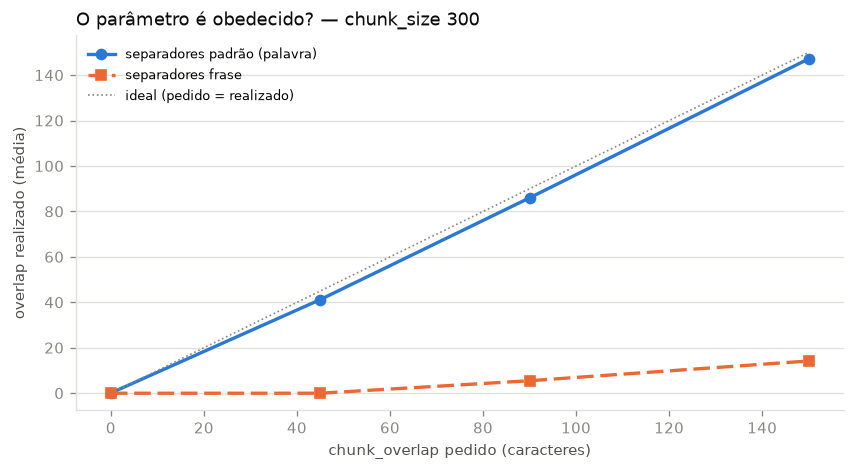

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4))
tabela_diag = pd.DataFrame(diagnostico)

estilos = {"padrão (palavra)": ("#2a78d6", "o", "-"), "frase": ("#eb6834", "s", (0, (5, 2)))}
for estrategia, (cor, marcador, traco) in estilos.items():
    sub = tabela_diag[(tabela_diag.separadores == estrategia) & (tabela_diag.chunk_size == 300)]
    ax.plot(sub["overlap pedido"], sub["overlap realizado (média)"],
            color=cor, marker=marcador, ls=traco, lw=2, ms=6, label=f"separadores {estrategia}")

ax.plot([0, 150], [0, 150], color=TINTA["suave"], lw=1, ls=":", label="ideal (pedido = realizado)")
ax.set_xlabel("chunk_overlap pedido (caracteres)")
ax.set_ylabel("overlap realizado (média)")
ax.set_title("O parâmetro é obedecido? — chunk_size 300", loc="left", fontsize=11, color=TINTA["primaria"])
ax.legend(fontsize=8, frameon=False)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

O gráfico mostra o problema com clareza. Com separadores de palavra, o overlap realizado
acompanha o pedido quase exatamente. Com separadores de frase, a linha fica **colada no
zero**: pedir 90 caracteres de overlap entrega 5,5 em média, e apenas 1 das 13 emendas
recebe alguma sobreposição.

O overlap só volta a funcionar com separadores de frase quando o orçamento passa a caber
uma frase inteira — em `chunk_size` 450 com overlap 225, o realizado salta para ~185.

**Consequência metodológica:** comparar configurações pelo `chunk_overlap` *pedido*
levaria a concluir que "o overlap não faz diferença", quando na verdade ele nunca
aconteceu. A análise da próxima seção usa os separadores de palavra, onde o parâmetro de
fato varia.

## 3. Como o overlap influencia a coesão entre chunks consecutivos

Duas medidas, porque uma sozinha engana:

- **coesão entre consecutivos** — similaridade de cosseno entre cada chunk e o seguinte.
  O overlap infla essa medida **mecanicamente**, já que os vizinhos passam a compartilhar
  texto literal;
- **fidelidade ao documento** — similaridade entre o chunk e o embedding do relato
  inteiro. O overlap não duplica texto nessa comparação, então ela mede quanto de
  contexto do relato o chunk ainda carrega.

In [6]:
TAMANHOS = [150, 300, 450]
FRACOES = [0.0, 0.15, 0.30]

configuracoes = {}
for tamanho in TAMANHOS:
    for fracao in FRACOES:
        overlap = int(tamanho * fracao)
        nome = f"{tamanho}/{overlap}"
        chunks = fatiar(longas, tamanho, overlap, "padrão (palavra)")
        configuracoes[nome] = {
            "chunk_size": tamanho, "chunk_overlap": overlap, "fracao": fracao,
            "chunks": chunks, "embeddings": gerar_embeddings(chunks.texto.tolist(), MODELO),
        }

embedding_documento = {
    r.id: e for r, e in zip(longas.itertuples(), gerar_embeddings(longas.texto.tolist(), MODELO))
}

def metricas(config):
    chunks, E = config["chunks"], config["embeddings"]
    consecutivos, com_documento = [], []
    for mid, grupo in chunks.groupby("id"):
        indices = grupo.sort_values("ordem").index.to_numpy()
        for a, b in zip(indices, indices[1:]):
            consecutivos.append(float(cosine_similarity(E[a:a + 1], E[b:b + 1])[0, 0]))
        for i in indices:
            com_documento.append(float(cosine_similarity(E[i:i + 1], embedding_documento[mid].reshape(1, -1))[0, 0]))
    return np.mean(consecutivos), np.mean(com_documento)

for nome, c in configuracoes.items():
    c["coesao"], c["fidelidade"] = metricas(c)

tabela_coesao = pd.DataFrame([
    {
        "config": nome, "chunk_size": c["chunk_size"], "overlap": c["chunk_overlap"],
        "overlap realizado": round(c["chunks"][c["chunks"].ordem > 0].overlap_com_anterior.mean(), 1),
        "coesão entre consecutivos": round(c["coesao"], 3),
        "fidelidade ao documento": round(c["fidelidade"], 3),
        "nº de chunks": len(c["chunks"]),
    }
    for nome, c in configuracoes.items()
])
tabela_coesao

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,config,chunk_size,overlap,overlap realizado,coesão entre consecutivos,fidelidade ao documento,nº de chunks
0,150/0,150,0,0.0,0.356,0.605,26
1,150/22,150,22,17.9,0.396,0.588,30
2,150/45,150,45,40.2,0.484,0.603,33
3,300/0,300,0,0.1,0.438,0.694,15
4,300/45,300,45,41.2,0.529,0.741,15
5,300/90,300,90,86.0,0.616,0.750,16
6,450/0,450,0,0.0,0.486,0.773,10
7,450/67,450,67,62.8,0.580,0.814,10
8,450/135,450,135,132.2,0.671,0.856,10


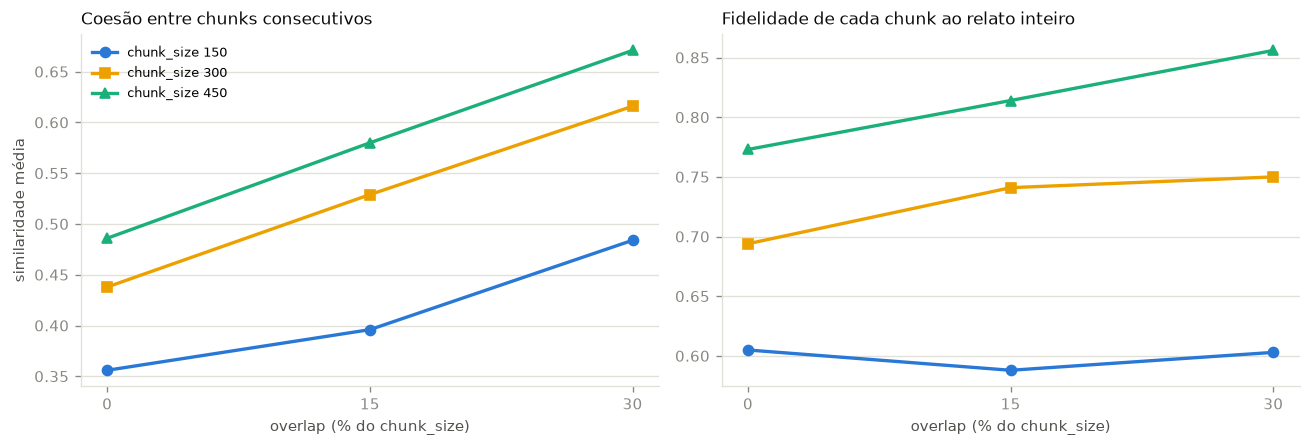

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
cores_tamanho = {150: "#2a78d6", 300: "#eda100", 450: "#1baf7a"}
marcadores = {150: "o", 300: "s", 450: "^"}

for tamanho in TAMANHOS:
    sub = tabela_coesao[tabela_coesao.chunk_size == tamanho].sort_values("overlap")
    eixo_x = [f * 100 for f in FRACOES]
    ax1.plot(eixo_x, sub["coesão entre consecutivos"], color=cores_tamanho[tamanho],
             marker=marcadores[tamanho], lw=2, ms=6, label=f"chunk_size {tamanho}")
    ax2.plot(eixo_x, sub["fidelidade ao documento"], color=cores_tamanho[tamanho],
             marker=marcadores[tamanho], lw=2, ms=6, label=f"chunk_size {tamanho}")

ax1.set_title("Coesão entre chunks consecutivos", loc="left", fontsize=10, color=TINTA["primaria"])
ax1.set_ylabel("similaridade média")
ax2.set_title("Fidelidade de cada chunk ao relato inteiro", loc="left", fontsize=10, color=TINTA["primaria"])
for ax in (ax1, ax2):
    ax.set_xlabel("overlap (% do chunk_size)")
    ax.set_xticks([0, 15, 30])
    ax.grid(axis="x", visible=False)
    ax.spines[["top", "right"]].set_visible(False)
ax1.legend(fontsize=7.5, frameon=False)
plt.tight_layout()
plt.show()

Agora que o overlap realmente acontece, as duas curvas sobem — e por motivos diferentes.

**A coesão sobe muito** (em `chunk_size` 300, de 0,438 para 0,616 entre 0% e 30%). Boa
parte disso é **inflação mecânica**: com 30% de overlap, quase um terço do texto de cada
chunk é cópia do anterior, e o cosseno reage a essa repetição, não a continuidade de
sentido. Essa medida sozinha não serve para escolher configuração.

**A fidelidade ao relato também sobe**, e essa é a evidência que interessa: em
`chunk_size` 300 ela vai de 0,694 para 0,750, e em 450 de 0,773 para 0,856. Como o
documento inteiro não contém texto duplicado, não há inflação possível aqui — o ganho
significa que cada chunk, com o pedaço herdado do vizinho, passa a carregar mais do
contexto do relato original.

O papel do overlap fica assim delimitado: ele **não** aumenta a informação do corpus, ele
**reduz a perda nas fronteiras**. E o efeito é tanto maior quanto menor o chunk, porque
chunks pequenos têm mais fronteiras por texto.

### O que se perde numa fronteira sem overlap

O caso concreto, com os separadores de frase (onde as fronteiras coincidem com o começo
das orações e o problema fica visível):

In [8]:
CONECTORES = (
    "além disso", "isso", "isto", "esse", "essa", "esses", "essas", "ele", "ela", "eles",
    "elas", "também", "então", "por isso", "o mesmo", "a mesma", "nesse", "nessa", "após",
    "depois", "durante", "assim", "lá", "ali", "tal", "mas", "porém", "contudo",
    "na última", "na semana",
)

def abertura_dependente(texto):
    """O chunk começa por um termo que aponta para algo que ficou no chunk anterior?"""
    inicio = texto.strip().lstrip(".,;: ").strip().lower()
    return any(inicio.startswith(c) for c in CONECTORES)

chunks_frase = fatiar(longas, 300, 0, "frase")
dependentes = chunks_frase[chunks_frase.texto.map(abertura_dependente)]

print(f"separadores de frase, 300/0: {len(dependentes)} de {len(chunks_frase)} chunks "
      f"({100 * len(dependentes) / len(chunks_frase):.0f}%) abrem dependendo do chunk anterior\n")
for r in dependentes.itertuples():
    print(f"[{r.chunk_id}] {r.texto[:96]!r}")

separadores de frase, 300/0: 4 de 18 chunks (22%) abrem dependendo do chunk anterior

[M007#2] 'Além disso, os ventiladores de duas salas queimaram em março e não foram substituídos, o que tor'
[M016#2] 'Na última visita, a técnica informou que a unidade está sem material e orientou a família a comp'
[M033#1] 'Durante a espera havia apenas um médico para toda a unidade e a sala de espera estava com cerca '
[M033#2] 'Após o atendimento, fomos informados de que o aparelho de nebulização estava quebrado e que deve'


Lido isoladamente — que é exatamente como o buscador o lê — o chunk `M007#2` diz que
*"os ventiladores de duas salas queimaram em março"*, mas **não diz de qual escola**, nem
que o assunto é infraestrutura escolar: o sujeito ficou no chunk anterior, e o conector
"Além disso" aponta para um antecedente ausente. O mesmo acontece com *"Na última
visita, a técnica informou..."* (qual visita? de quem?) e *"Após o atendimento, fomos
informados..."*.

É essa perda que o overlap conserta, e é por isso que ela não aparece na média de
similaridade: são poucos chunks, mas são justamente os que ficam irrecuperáveis numa
busca.

Note que os separadores de palavra marcam 0% nessa métrica — não porque sejam melhores,
mas porque falham de outro jeito: seus chunks começam no meio de uma oração qualquer
(*"...uma situação que já dura"*), então não começam por conector nenhum. A métrica
detecta um modo de falha, não os dois.

## 4. Qual configuração preserva melhor o sentido? O teste de recuperação

Médias de similaridade não dizem se o chunking **funciona**. O teste que importa é o do
app da Entrega 4: o cidadão digita uma descrição e o sistema precisa devolver a
manifestação certa.

As consultas abaixo miram informações **enterradas no meio** dos relatos longos —
justamente o que um vetor de documento inteiro dilui. Além da posição, medimos a
**margem**: a distância entre o primeiro e o segundo colocados. Margem grande significa
um resultado seguro, não um empate resolvido por acaso.

In [9]:
CONSULTAS = [
    ("ventilador queimado na sala de aula sem substituição", "M007"),
    ("aparelho de nebulização quebrado no pronto atendimento", "M033"),
    ("troca de sonda atrasada em paciente acamado", "M016"),
    ("lixeiras retiradas do parque e nunca recolocadas", "M040"),
    ("viatura demora e o grupo já se dispersou", "M023"),
]

E_corpus = gerar_embeddings(df.texto.tolist(), MODELO)
ids_corpus = df.id.tolist()

def ranquear(consulta, esperado, chunks=None, E=None):
    """Posição e margem da manifestação esperada. Sem chunks, usa o índice de documentos."""
    q = gerar_embeddings([consulta], MODELO)
    if chunks is None:
        ordenado = pd.Series(cosine_similarity(q, E_corpus).ravel(), index=ids_corpus)
    else:
        # cada manifestação recebe o score do seu melhor chunk
        ordenado = chunks.assign(score=cosine_similarity(q, E).ravel()).groupby("id").score.max()
    ordenado = ordenado.sort_values(ascending=False)
    return list(ordenado.index).index(esperado) + 1, float(ordenado.iloc[0] - ordenado.iloc[1])

INDICES = [("documento inteiro", None)] + [(f"chunks {n}", n) for n in ["150/0", "150/45", "300/0", "300/90", "450/135"]]

linhas = []
for rotulo, nome in INDICES:
    for consulta, esperado in CONSULTAS:
        if nome is None:
            posicao, margem = ranquear(consulta, esperado)
        else:
            c = configuracoes[nome]
            posicao, margem = ranquear(consulta, esperado, c["chunks"], c["embeddings"])
        linhas.append({"índice": rotulo, "consulta": consulta[:42], "posição": posicao, "margem": round(margem, 3)})

recuperacao = pd.DataFrame(linhas)
resumo = recuperacao.groupby("índice", sort=False).agg(
    acertos_em_1o=("posição", lambda s: f"{int((s == 1).sum())}/5"),
    posicao_media=("posição", "mean"),
    margem_media=("margem", "mean"),
).round(3)

display(resumo)
recuperacao.pivot(index="consulta", columns="índice", values="posição")[[r for r, _ in INDICES]]

,acertos_em_1o,posicao_media,margem_media
índice,,,
documento inteiro,4/5,1.2,0.077
chunks 150/0,5/5,1.0,0.226
chunks 150/45,5/5,1.0,0.242
chunks 300/0,5/5,1.0,0.202
chunks 300/90,5/5,1.0,0.234
chunks 450/135,5/5,1.0,0.198


índice,documento inteiro,chunks 150/0,chunks 150/45,chunks 300/0,chunks 300/90,chunks 450/135
consulta,,,,,,
aparelho de nebulização quebrado no pronto,2,1,1,1,1,1
lixeiras retiradas do parque e nunca recol,1,1,1,1,1,1
troca de sonda atrasada em paciente acamad,1,1,1,1,1,1
ventilador queimado na sala de aula sem su,1,1,1,1,1,1
viatura demora e o grupo já se dispersou,1,1,1,1,1,1


O índice de documentos inteiros erra uma das cinco consultas: quem procura
*"aparelho de nebulização quebrado no pronto atendimento"* recebe `M033` apenas em
**segundo lugar**, embora o aparelho quebrado esteja literalmente escrito nela. O detalhe
está na última frase de um relato de 668 caracteres dominado por febre, fila de espera e
classificação de risco — e o vetor único do documento representa essa média, não o
detalhe.

Todas as configurações de chunk acertam as cinco consultas, e a margem de todas (0,198 a
0,242) é cerca de **três vezes** a do documento inteiro (0,077). O ganho de chunkar é
grande e inequívoco.

**Entre as configurações, porém, este teste não decide nada.** As margens ficam num
intervalo estreito e a ordem não é a esperada — `150/45` marca 0,242 e `300/90`, 0,234.
Com cinco consultas, uma diferença de 0,008 é ruído, não evidência: bastaria trocar uma
consulta para inverter o pódio. Concluir que "150/45 é a melhor configuração" a partir
daqui seria ler sinal onde só existe variação amostral.

A escolha da configuração, portanto, tem de se apoiar em outro critério — o que a próxima
seção e a conclusão discutem.

## 5. Os chunks de uma mesma manifestação ficam próximos?

Projeção em 2D dos chunks da configuração recomendada. Cada cor **e** cada formato
identificam a manifestação de origem; a linha liga os chunks na ordem em que aparecem no
texto; o marcador vazado é o embedding do **documento inteiro**.

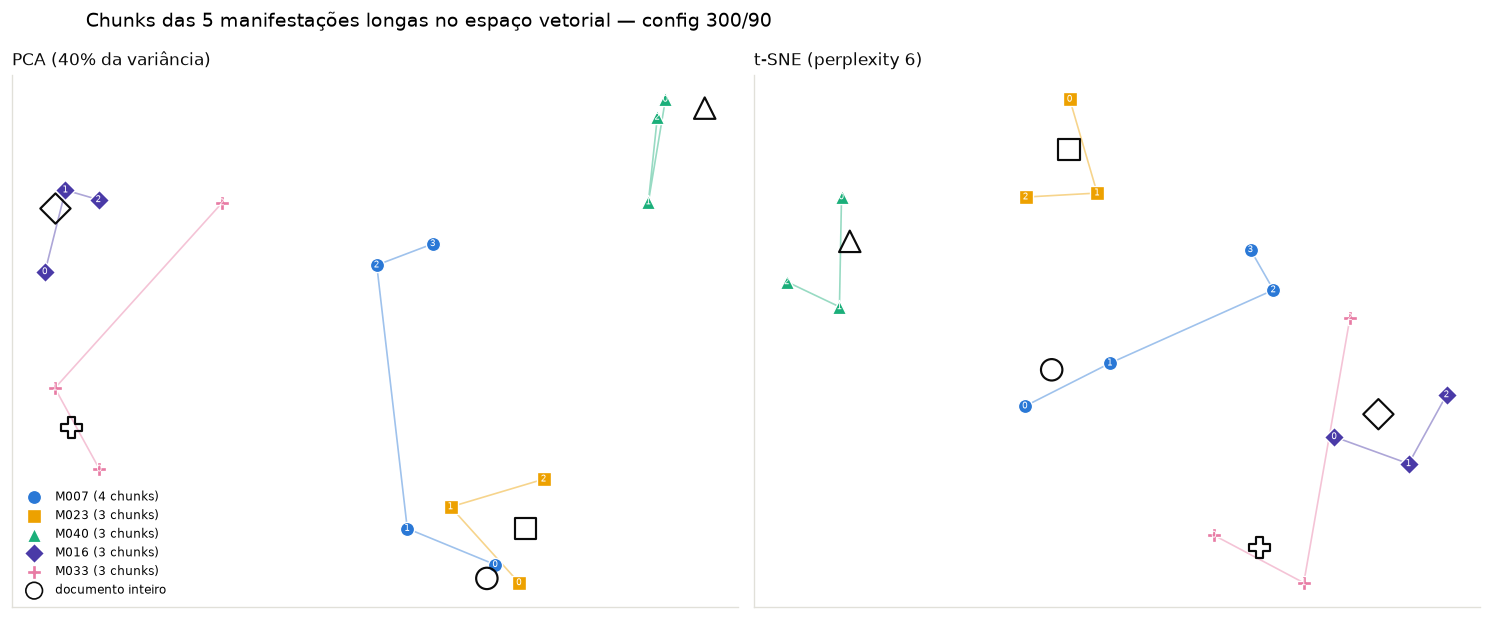

In [10]:
CONFIG_VIZ = "300/90"
chunks_viz = configuracoes[CONFIG_VIZ]["chunks"]
E_viz = configuracoes[CONFIG_VIZ]["embeddings"]

E_docs = np.vstack([embedding_documento[m] for m in longas.id])
E_todos = np.vstack([E_viz, E_docs])

pca = PCA(n_components=2, random_state=0)
proj_pca = pca.fit_transform(E_todos)

tsne = TSNE(n_components=2, perplexity=6, learning_rate="auto", init="pca", random_state=0)
proj_tsne = tsne.fit_transform(E_todos)

CORES = dict(zip(longas.id, ["#2a78d6", "#eda100", "#1baf7a", "#4a3aa7", "#e87ba4"]))
FORMAS = dict(zip(longas.id, ["o", "s", "^", "D", "P"]))
n_chunks = len(chunks_viz)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
painéis = [
    (axes[0], proj_pca, f"PCA ({100 * pca.explained_variance_ratio_.sum():.0f}% da variância)"),
    (axes[1], proj_tsne, "t-SNE (perplexity 6)"),
]

for ax, proj, titulo in painéis:
    for mid in longas.id:
        mascara = (chunks_viz.id == mid).to_numpy()
        sub = chunks_viz[mascara].sort_values("ordem")
        pontos = proj[:n_chunks][sub.index.to_numpy()]
        ax.plot(pontos[:, 0], pontos[:, 1], color=CORES[mid], lw=1, alpha=0.45, zorder=2)
        ax.scatter(pontos[:, 0], pontos[:, 1], s=72, color=CORES[mid], marker=FORMAS[mid],
                   edgecolor="white", linewidth=0.8, label=f"{mid} ({len(sub)} chunks)", zorder=3)
        for (x, y), ordem in zip(pontos, sub.ordem):
            ax.annotate(str(ordem), (x, y), fontsize=5.5, ha="center", va="center",
                        color="white", zorder=4)

    for k, mid in enumerate(longas.id):
        ax.scatter(*proj[n_chunks + k], s=165, facecolor="none", edgecolor=TINTA["primaria"],
                   linewidth=1.3, marker=FORMAS[mid], zorder=5)

    ax.set_title(titulo, loc="left", fontsize=10, color=TINTA["primaria"])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].scatter([], [], s=100, facecolor="none", edgecolor=TINTA["primaria"], label="documento inteiro")
axes[0].legend(fontsize=7, frameon=False, loc="best")
fig.suptitle(f"Chunks das 5 manifestações longas no espaço vetorial — config {CONFIG_VIZ}",
             x=0.06, ha="left", fontsize=11.5)
plt.tight_layout()
plt.show()

In [11]:
# Medida objetiva: um chunk se parece mais com os irmãos ou com chunks de outros relatos?
S_chunks = cosine_similarity(E_viz)
ids_chunk = chunks_viz.id.to_numpy()

linhas = []
for mid in longas.id:
    dentro, fora = [], []
    for a in np.where(ids_chunk == mid)[0]:
        for b in range(len(ids_chunk)):
            if a == b:
                continue
            (dentro if ids_chunk[b] == mid else fora).append(S_chunks[a, b])
    linhas.append({
        "manifestação": mid,
        "chunks": int((ids_chunk == mid).sum()),
        "média entre irmãos": round(float(np.mean(dentro)), 3),
        "média com outros relatos": round(float(np.mean(fora)), 3),
        "separação": round(float(np.mean(dentro) - np.mean(fora)), 3),
    })

coesao_interna = pd.DataFrame(linhas)
display(coesao_interna)
print(f"Separação média: {coesao_interna['separação'].mean():.3f} — positiva em "
      f"{(coesao_interna['separação'] > 0).sum()} das {len(coesao_interna)} manifestações")

,manifestação,chunks,média entre irmãos,média com outros relatos,separação
0,M007,4,0.461,0.347,0.114
1,M023,3,0.670,0.336,0.334
2,M040,3,0.657,0.284,0.373
3,M016,3,0.621,0.312,0.309
4,M033,3,0.372,0.310,0.062


Separação média: 0.238 — positiva em 5 das 5 manifestações


### Resposta: sim, mas sem colapsar em um ponto

Nos dois métodos de projeção os chunks de uma mesma manifestação formam grupos visíveis,
e a medida objetiva confirma: em todas as cinco manifestações um chunk é mais parecido
com seus irmãos do que com chunks de outros relatos.

Os grupos, porém, **não são apertados** — e não deveriam ser. Um relato longo de ouvidoria
é multi-assunto por natureza: em `M007`, o chunk sobre goteiras no telhado e o chunk sobre
protocolos ignorados na Secretaria tratam de coisas genuinamente diferentes, e o espaço
vetorial os afasta com razão. A linha que liga os chunks na ordem do texto desenha esse
percurso temático dentro do próprio relato.

O marcador vazado do **documento inteiro** costuma cair no meio da nuvem dos seus chunks:
visualmente, é a "média" de que falávamos na abertura. É exatamente por isso que ele não
representa bem nenhum dos assuntos e perde a consulta sobre o aparelho de nebulização.

Uma observação sobre PCA e t-SNE: o PCA preserva distâncias globais mas explica pouca
variância em duas dimensões (embeddings de 384 dimensões não cabem em 2), então grupos
distintos podem se sobrepor na projeção. O t-SNE separa melhor visualmente, mas as
distâncias **entre** grupos não são interpretáveis — apenas a vizinhança local é. Por
isso a tabela numérica acima, calculada no espaço original de 384 dimensões, é a
evidência, e os gráficos são ilustração.

## Conclusões

**Como o overlap influencia a coesão entre chunks consecutivos?** Aumentando-a, mas o
número engana duas vezes. Primeiro, porque uma parte do aumento é **mecânica**: chunks
vizinhos com 30% de overlap compartilham texto literal, e o cosseno reage à repetição
(coesão de 0,438 para 0,616 em `chunk_size` 300). Segundo — e mais importante — porque o
overlap **pode simplesmente não acontecer**: com separadores de frase, pedir 90 caracteres
de sobreposição entrega 5,5, já que o splitter gasta o orçamento em unidades de frase e
uma frase inteira não cabe nele. A evidência de ganho real é a **fidelidade ao relato de
origem** (0,694 → 0,750 em 300; 0,773 → 0,856 em 450), que não pode ser inflada por
repetição: com o trecho herdado do vizinho, cada chunk carrega mais contexto do documento
original. Em resumo, o overlap não acrescenta informação — ele **reduz a perda nas
fronteiras**, e vale mais quanto menor o chunk, porque chunks menores têm mais fronteiras.

**Qual configuração preserva melhor o sentido das denúncias?** `chunk_size` 300 com
`chunk_overlap` 90 (30%). Antes da justificativa, o que os dados **não** sustentam: o
teste de recuperação mostra um ganho claro de chunkar (margem ~3× a do documento
inteiro), mas não distingue as configurações entre si — as cinco acertam as cinco
consultas, com margens dentro do ruído amostral. Escolher pelo primeiro lugar dessa
tabela seria arbitrário.

O critério que resta é a **fidelidade ao relato de origem**, e ele precisa ser lido com
cuidado, porque não é uma métrica a maximizar: um chunk que reproduzisse o documento
inteiro teria fidelidade 1,0 e anularia o propósito do chunking. O que se busca é o ponto
em que o chunk é **pequeno o bastante para isolar um assunto** e **grande o bastante para
se sustentar sozinho**. Nessa leitura:

- em 150 caracteres a fidelidade estaciona em ~0,60 mesmo com overlap — o pedaço mal
  comporta uma frase da denúncia, e o vetor sai genérico;
- em 300 ela chega a 0,750, e o chunk passa a conter uma ou duas frases completas, que é
  a unidade em que o cidadão descreve **um** dos problemas do relato;
- em 450 ela sobe a 0,856, mas o chunk volta a abrigar assuntos distintos no mesmo vetor —
  caminho de volta à diluição que motivou o chunking.

Somando-se a isso que o overlap de 90 se realiza de fato (86 caracteres medidos) e
recupera casos como o chunk que abre em *"Além disso, os ventiladores de duas salas
queimaram"* — que sozinho não menciona escola alguma —, `300/90` é a configuração
recomendada.

Há um porém honesto: os separadores de palavra cortam no meio da frase, o que é ruim
quando o chunk é **exibido a uma pessoa** — e o app da Entrega 4 exibe. Para esse uso, a
alternativa é `chunk_size` 450 com `chunk_overlap` 225 e separadores de frase: é a única
combinação em que o overlap se realiza (~185 caracteres) *e* os chunks terminam em
fronteira gramatical. O custo é dobrar o texto armazenado e voltar a misturar assuntos no
mesmo vetor. A escolha, portanto, depende de quem lê o chunk: a máquina ou o cidadão.

**Os chunks de uma mesma manifestação ficam próximos no espaço 2D?** Sim — formam grupos
identificáveis em PCA e t-SNE, com separação positiva entre irmãos e não-irmãos nas cinco
manifestações. Mas ficam próximos **sem colapsar**, e essa dispersão é o objetivo: se os
chunks fossem idênticos entre si, dividir o texto não teria trazido nenhuma informação
além do vetor único do documento.